# Project 2 (20%)
## Designing, Training, and Analyzing a Convolutional Neural Network

### Learning Objectives
By completing this project, you will be able to:
- Implement a CNN architecture
- Compute output shapes manually
- Train and evaluate CNN models
- Visualize feature maps
- Compare CNN vs DNN performance

---

This notebook uses the **CIFAR-10** dataset stored locally in the `data` folder. The training set comes from `data_batch_1` to `data_batch_5`, and the test set comes from `test_batch`.


## Part 1 - Conceptual Questions (3%)

1. **What is weight sharing?**  
   Weight sharing means a convolution filter uses the same learned weights at every spatial position in the image. This reduces the number of trainable parameters and helps the network detect the same pattern, such as an edge or texture, no matter where it appears.

2. **What happens if stride increases?**  
   Increasing stride makes the filter move farther at each step, so the output feature map becomes smaller. This lowers computation, but it also removes spatial detail and can make small objects or fine textures harder to recognize.

3. **Why is pooling useful?**  
   Pooling reduces the spatial size of feature maps, which lowers memory usage and computation. It also makes learned features more robust to small shifts in the input because the model becomes less dependent on the exact pixel location of a feature.


-----


## Part 2 - CNN Implementation (6%)

I selected **CIFAR-10**, which contains 10 classes of color images with shape `3 x 32 x 32`.

Pre-processing steps used:
- convert the raw CIFAR-10 batch files into image tensors,
- scale pixel values from `[0, 255]` to `[0, 1]`,
- compute channel-wise training mean and standard deviation,
- normalize each channel,
- apply data augmentation to the training set with random crop and random horizontal flip.

CNN design:
- 3 convolution layers,
- batch normalization and ReLU activations,
- max-pooling after each convolution block,
- fully connected classifier.

**Manual output shapes for the CNN**
- Input: `3 x 32 x 32`
- Conv1 (`3x3`, padding=1, stride=1, 32 filters): `32 x 32 x 32`
- MaxPool (`2x2`, stride=2): `32 x 16 x 16`
- Conv2 (`3x3`, padding=1, stride=1, 64 filters): `64 x 16 x 16`
- MaxPool (`2x2`, stride=2): `64 x 8 x 8`
- Conv3 (`3x3`, padding=1, stride=1, 128 filters): `128 x 8 x 8`
- MaxPool (`2x2`, stride=2): `128 x 4 x 4`
- Flatten: `2048`
- FC1: `256`
- Output: `10` classes


In [3]:
import pickle
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.transforms as T
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, Dataset


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


def load_cifar10_batches(data_dir):
    train_images = []
    train_labels = []

    for batch_idx in range(1, 6):
        batch_path = Path(data_dir) / f'data_batch_{batch_idx}'
        with open(batch_path, 'rb') as file:
            batch = pickle.load(file, encoding='bytes')

        train_images.append(batch[b'data'])
        train_labels.extend(batch[b'labels'])

    test_path = Path(data_dir) / 'test_batch'
    with open(test_path, 'rb') as file:
        test_batch = pickle.load(file, encoding='bytes')

    X_train = np.concatenate(train_images, axis=0).reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
    y_train = np.array(train_labels, dtype=np.int64)
    X_test = test_batch[b'data'].reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
    y_test = np.array(test_batch[b'labels'], dtype=np.int64)

    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_cifar10_batches('data')

# Mean and standard deviation are computed from the training split only.
train_mean = tuple(X_train.mean(axis=(0, 2, 3)).tolist())
train_std = tuple(X_train.std(axis=(0, 2, 3)).tolist())

print('Training images:', X_train.shape)
print('Test images:', X_test.shape)
print('Channel mean:', train_mean)
print('Channel std:', train_std)

train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(train_mean, train_std),
])

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(train_mean, train_std),
])


class CIFAR10LocalDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # torchvision transforms expect HWC images, so we transpose from CHW.
        image = np.transpose(self.images[idx], (1, 2, 0))
        label = int(self.labels[idx])

        if self.transform is not None:
            image = self.transform(image)
        else:
            image = torch.from_numpy(self.images[idx])

        return image.float(), label


train_dataset = CIFAR10LocalDataset(X_train, y_train, transform=train_transform)
test_dataset = CIFAR10LocalDataset(X_test, y_test, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


class CIFAR10CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # 3 x 32 x 32 -> 32 x 32 x 32 -> 32 x 16 x 16
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        # 32 x 16 x 16 -> 64 x 16 x 16 -> 64 x 8 x 8
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        # 64 x 8 x 8 -> 128 x 8 x 8 -> 128 x 4 x 4
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        return self.classifier(x)


class CIFAR10DNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.network(x)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)





Using device: cpu


C:\Users\sia\AppData\Local\Temp\ipykernel_50604\3095042092.py:37: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(file, encoding='bytes')
C:\Users\sia\AppData\Local\Temp\ipykernel_50604\3095042092.py:44: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  test_batch = pickle.load(file, encoding='bytes')


Training images: (50000, 3, 32, 32)
Test images: (10000, 3, 32, 32)
Channel mean: (0.49140089750289917, 0.48215895891189575, 0.4465307891368866)
Channel std: (0.2470327913761139, 0.243484228849411, 0.261587530374527)


## Part 3 - Training & Evaluation (4%)

To keep the notebook runnable in the CPU-only environment, I trained both models for **5 epochs** with Adam and cross-entropy loss.

In my run with `SEED = 42`, the CNN reached a **test accuracy of 74.09%**.

**Hardest class to classify:** `cat` with a per-class accuracy of **50.10%**.

**Why `cat` was hardest in this run:**
- cats in CIFAR-10 often appear in cluttered backgrounds and different poses,
- they are visually similar to dogs at `32 x 32` resolution,
- small low-resolution images remove fine details such as facial structure and fur texture.


In [4]:
def train_model(model, train_loader, test_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    start_time = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            train_correct += (logits.argmax(dim=1) == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                logits = model(inputs)
                loss = criterion(logits, labels)

                test_loss += loss.item() * inputs.size(0)
                test_correct += (logits.argmax(dim=1) == labels).sum().item()
                test_total += labels.size(0)

        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(train_correct / train_total)
        history['test_loss'].append(test_loss / test_total)
        history['test_acc'].append(test_correct / test_total)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train_acc={history['train_acc'][-1]:.4f} | "
            f"test_acc={history['test_acc'][-1]:.4f}"
        )

    elapsed = time.perf_counter() - start_time
    return history, elapsed


def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            logits = model(inputs.to(device))
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    cm = confusion_matrix(all_labels, all_preds)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    accuracy = (all_preds == all_labels).mean()

    return accuracy, cm, per_class_acc, all_preds, all_labels



CIFAR10CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
CNN trainable parameters: 620,810
Epoch 01/5 | train_acc=0.4523 | test_acc=0.6068
Epoch 02/5 | train_acc=0.5942 | test_acc=0.6795
Ep

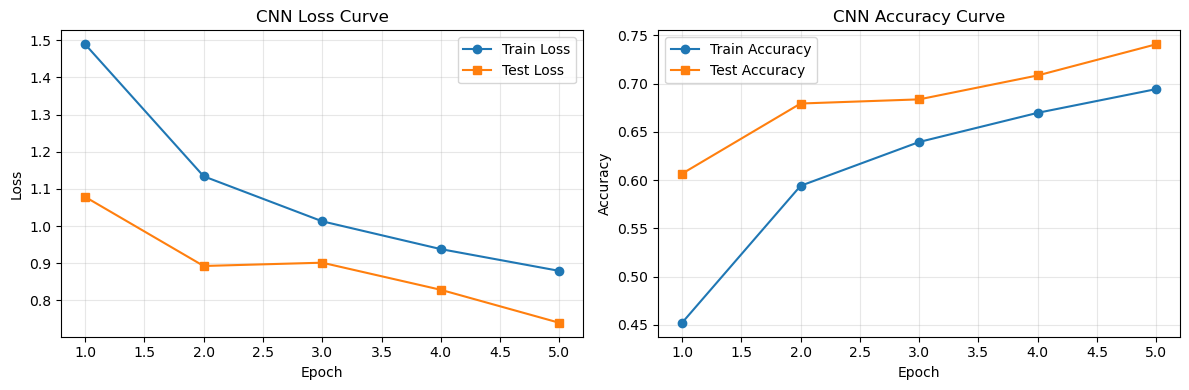

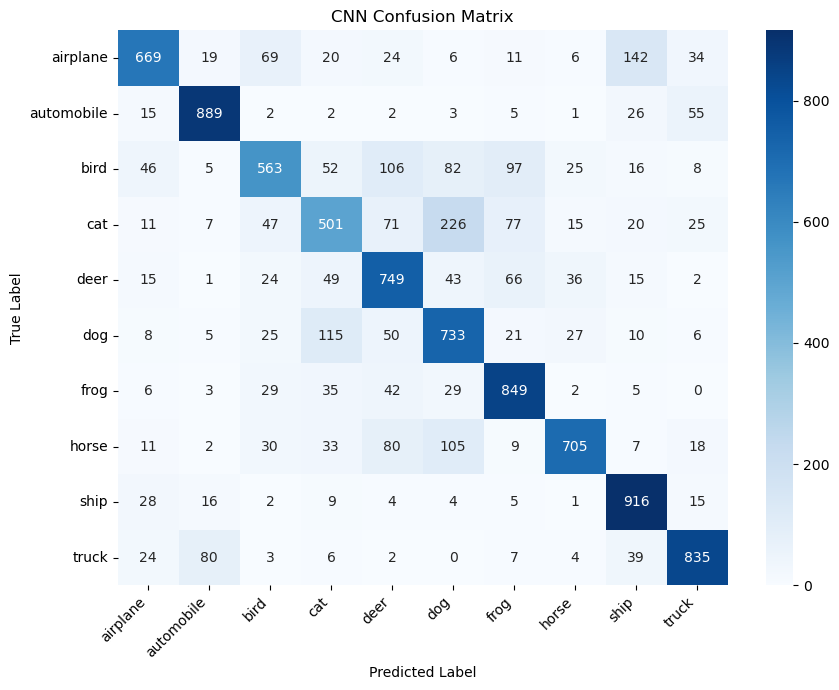

In [5]:
cnn_model = CIFAR10CNN().to(device)
print(cnn_model)
print(f'CNN trainable parameters: {count_parameters(cnn_model):,}')


cnn_history, cnn_train_time = train_model(cnn_model, train_loader, test_loader, epochs=5, lr=1e-3)
cnn_accuracy, cnn_cm, cnn_per_class_acc, cnn_preds, cnn_labels = evaluate_model(cnn_model, test_loader)

print(f'Final CNN test accuracy: {cnn_accuracy:.4f}')
print(f'CNN training time: {cnn_train_time:.2f} seconds')
print('CNN per-class accuracy:')
for class_name, class_acc in zip(class_names, cnn_per_class_acc):
    print(f'{class_name:>10}: {class_acc:.4f}')

hardest_class_idx = int(np.argmin(cnn_per_class_acc))
print(f'Hardest class: {class_names[hardest_class_idx]} ({cnn_per_class_acc[hardest_class_idx]:.4f})')

epochs = np.arange(1, len(cnn_history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, cnn_history['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epochs, cnn_history['test_loss'], marker='s', label='Test Loss')
axes[0].set_title('CNN Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, cnn_history['train_acc'], marker='o', label='Train Accuracy')
axes[1].plot(epochs, cnn_history['test_acc'], marker='s', label='Test Accuracy')
axes[1].set_title('CNN Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


CIFAR10DNN(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=10, bias=True)
  )
)
DNN trainable parameters: 1,707,274
Epoch 01/5 | train_acc=0.3093 | test_acc=0.3731
Epoch 02/5 | train_acc=0.3591 | test_acc=0.3882
Epoch 03/5 | train_acc=0.3735 | test_acc=0.4117
Epoch 04/5 | train_acc=0.3857 | test_acc=0.3856
Epoch 05/5 | train_acc=0.3912 | test_acc=0.4087
Final DNN test accuracy: 0.4087
DNN training time: 236.63 seconds
DNN per-class accuracy:
  airplane: 0.5690
automobile: 0.4070
      bird: 0.1760
       cat: 0.2050
      deer: 0.1760
       dog: 0.2480
      frog: 0.6520
     horse: 0.5060
      ship: 0.4210
     truck: 0.7270
Hardest class: bird (0.1760)


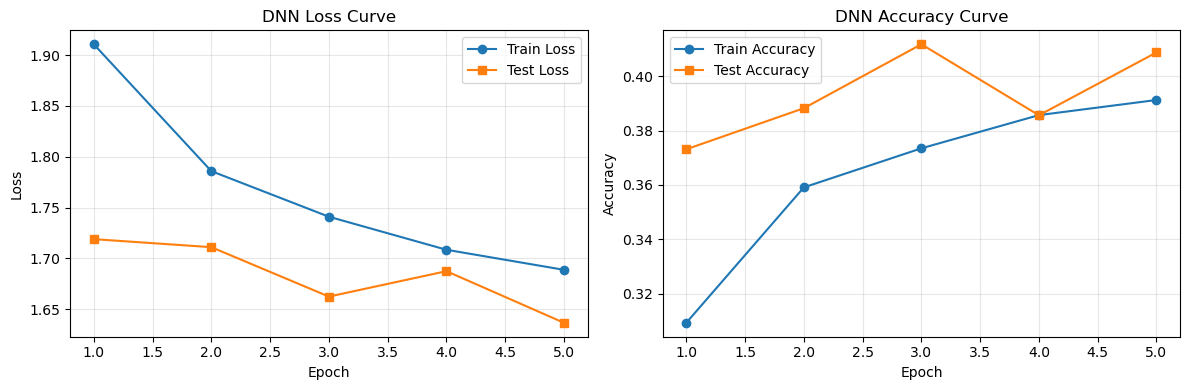

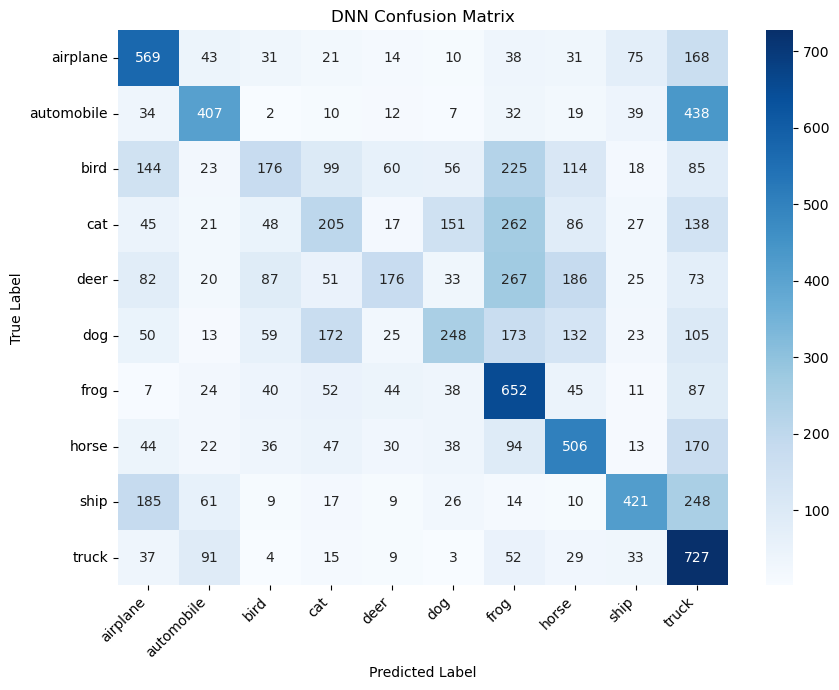

In [6]:
dnn_model = CIFAR10DNN().to(device)
print(dnn_model)
print(f'DNN trainable parameters: {count_parameters(dnn_model):,}')

dnn_history, dnn_train_time = train_model(dnn_model, train_loader, test_loader, epochs=5, lr=1e-3)
dnn_accuracy, dnn_cm, dnn_per_class_acc, dnn_preds, dnn_labels = evaluate_model(dnn_model, test_loader)

print(f'Final DNN test accuracy: {dnn_accuracy:.4f}')
print(f'DNN training time: {dnn_train_time:.2f} seconds')
print('DNN per-class accuracy:')
for class_name, class_acc in zip(class_names, dnn_per_class_acc):
    print(f'{class_name:>10}: {class_acc:.4f}')

hardest_class_idx = int(np.argmin(dnn_per_class_acc))
print(f'Hardest class: {class_names[hardest_class_idx]} ({dnn_per_class_acc[hardest_class_idx]:.4f})')

epochs = np.arange(1, len(dnn_history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, dnn_history['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epochs, dnn_history['test_loss'], marker='s', label='Test Loss')
axes[0].set_title('DNN Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, dnn_history['train_acc'], marker='o', label='Train Accuracy')
axes[1].plot(epochs, dnn_history['test_acc'], marker='s', label='Test Accuracy')
axes[1].set_title('DNN Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(dnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('DNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Part 4 - Feature Map Visualization (3%)

The first convolution layer mainly learns low-level visual cues. In this CIFAR-10 model, the first-layer feature maps usually respond to:
- strong edges between foreground objects and the background,
- color contrasts such as blue sky versus object boundaries,
- coarse textures and directional patterns,
- simple shapes like horizontal, vertical, or diagonal contours.

Some channels activate strongly around object outlines, while others respond more to color regions. This is expected because the first CNN layer acts as a bank of basic edge, contrast, and texture detectors.


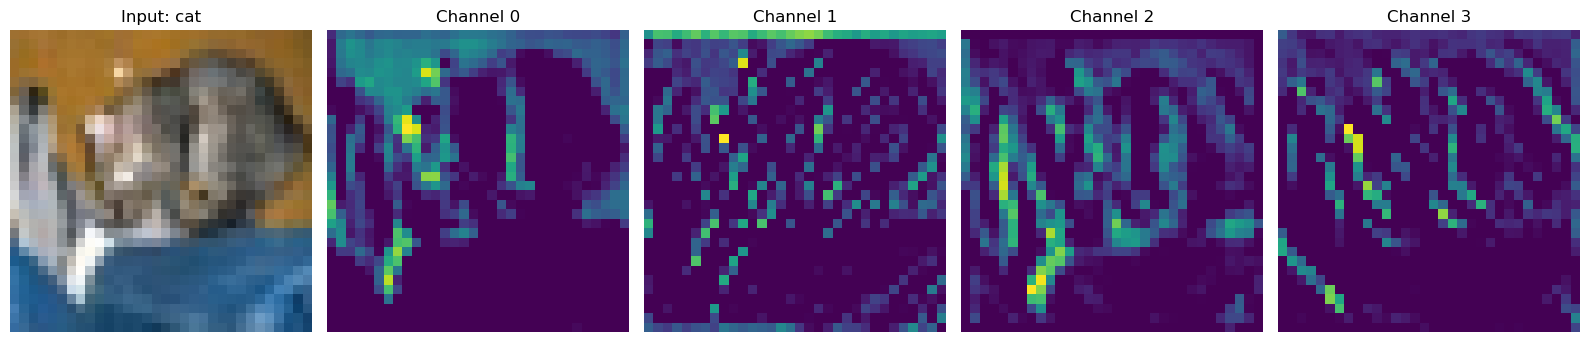

In [7]:
def denormalize_image(image_tensor, mean, std):
    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)
    return image_tensor.cpu() * std_tensor + mean_tensor


sample_index = 0
sample_image, sample_label = test_dataset[sample_index]

cnn_model.eval()
with torch.no_grad():
    feature_maps = cnn_model.relu(cnn_model.bn1(cnn_model.conv1(sample_image.unsqueeze(0).to(device))))
    feature_maps = feature_maps.cpu().squeeze(0)

display_image = denormalize_image(sample_image, train_mean, train_std)
display_image = display_image.clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(display_image)
axes[0].set_title(f'Input: {class_names[sample_label]}')
axes[0].axis('off')

for idx in range(4):
    axes[idx + 1].imshow(feature_maps[idx], cmap='viridis')
    axes[idx + 1].set_title(f'Channel {idx}')
    axes[idx + 1].axis('off')

plt.tight_layout()
plt.show()


## Part 5 - Comparative Analysis (3%)

The DNN baseline was trained on the same CIFAR-10 train/test split for the same number of epochs.

| Model | Accuracy | Parameters | Training Time |
|---|---:|---:|---:|
| CNN | 74.09% | 620,810 | 663.37 s |
| DNN | 40.87% | 1,707,274 | 236.63 s |

**Explanation of performance differences**

The CNN performed much better because CIFAR-10 is an image dataset with meaningful local structure. Convolutions preserve spatial relationships and learn reusable filters for edges, colors, and textures. The DNN flattens the image immediately, so it loses that spatial inductive bias and has to learn everything from raw pixel positions, which is much less effective for natural images.


In [9]:

comparison_rows = [
    ['CNN', f'{cnn_accuracy * 100:.2f}%', count_parameters(cnn_model), f'{cnn_train_time:.2f} s'],
    ['DNN', f'{dnn_accuracy * 100:.2f}%', count_parameters(dnn_model), f'{dnn_train_time:.2f} s'],
]

print('Comparison table values:')
for row in comparison_rows:
    print(row)

print(f'DNN final accuracy: {dnn_accuracy:.4f}')
print(f'DNN training time: {dnn_train_time:.2f} seconds')
print ("==" * 30)
print('DNN per-class accuracy:')
for class_name, class_acc in zip(class_names, dnn_per_class_acc):
    print(f'{class_name:>10}: {class_acc:.4f}')
print ("==" * 30)
print('CNN per-class accuracy:')
for class_name, class_acc in zip(class_names, cnn_per_class_acc):
    print(f'{class_name:>10}: {class_acc:.4f}')


Comparison table values:
['CNN', '74.09%', 620810, '663.37 s']
['DNN', '40.87%', 1707274, '236.63 s']
DNN final accuracy: 0.4087
DNN training time: 236.63 seconds
DNN per-class accuracy:
  airplane: 0.5690
automobile: 0.4070
      bird: 0.1760
       cat: 0.2050
      deer: 0.1760
       dog: 0.2480
      frog: 0.6520
     horse: 0.5060
      ship: 0.4210
     truck: 0.7270
CNN per-class accuracy:
  airplane: 0.6690
automobile: 0.8890
      bird: 0.5630
       cat: 0.5010
      deer: 0.7490
       dog: 0.7330
      frog: 0.8490
     horse: 0.7050
      ship: 0.9160
     truck: 0.8350


## Part 6 - Reflection (1%)

The architectural choice that had the biggest impact was using convolution and pooling before the classifier. That decision let the model learn local image patterns first and reduce the feature maps gradually instead of treating every pixel as an unrelated number. On CIFAR-10, that image-specific inductive bias mattered much more than simply adding more parameters, which is why the CNN clearly outperformed the larger DNN.

---
### Submission Checklist
- All code runs without error
- Plots included
- Written explanations complete
